In [1]:
from explore_m2f_finetune import Mask2FormerWrapper

In [ ]:
# input processing
import PIL
from PIL import Image
import torch
from torchvision.transforms import v2
import numpy as np

transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Resize(size=(1024, 1024), antialias=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Usage becomes a one-liner
path = "/home/satoshi/projects/wbcas/data/PBC/pbcseg_final_v1/EO_272663_ccrop.jpg"
path = "/home/satoshi.tsutsui/satoshissd/PBC/pbcseg_final_v1/EO_272663_ccrop.jpg"
image = Image.open(path)
image_tensor = transform(image)

In [3]:
import pandas as pd
path = "/home/satoshi/projects/wbcas/dataset_txt/pbc_attr_v1_ccrop_all.csv"
root = "/home/satoshi/projects/wbcas/data/PBC/pbcseg_final_v1/"

path = "/home/satoshi.tsutsui/projects/wbcas/dataset_txt/pbc_attr_v1_ccrop_all.csv"
root = "/home/satoshi.tsutsui/projects/wbcas/data/PBC/pbcseg_final_v1/"

df = pd.read_csv(path)
df['img_path'] = root + df['img_name']
df['mask_path'] = df['img_path'].apply(lambda x: x.replace(".jpg", "_mask.png"))


In [4]:
df_train = df[df['split']=="train"].copy().reset_index(drop=True)
df_val = df[df['split']=="val"].copy().reset_index(drop=True)
df_test = df[df['split']=="test"].copy().reset_index(drop=True)

# ds_test = SegDataset(df=df_test,transform=transform)

# visualize one

In [5]:
checkpoint_path = "./experiments.keep/m2f_tiny_1024_color_20260414_091312/model_epoch=050.ckpt"
model_name = "facebook/mask2former-swin-tiny-ade-semantic"
seg_model = Mask2FormerWrapper(model_name, num_classes=6,out_resolution=360).to("cuda")
checkpoint = torch.load(checkpoint_path,weights_only=False)
print(seg_model.load_state_dict(checkpoint['model_state_dict']))
seg_model = seg_model.cuda().eval()

You passed `num_labels=6` which is incompatible to the `id2label` map of length `150`.


Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

Mask2FormerForUniversalSegmentation LOAD REPORT from: facebook/mask2former-swin-tiny-ade-semantic
Key                    | Status   |                                                                                         
-----------------------+----------+-----------------------------------------------------------------------------------------
class_predictor.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([151, 256]) vs model:torch.Size([7, 256])
class_predictor.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([151]) vs model:torch.Size([7])          
criterion.empty_weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([151]) vs model:torch.Size([7])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


<All keys matched successfully>


In [ ]:
# compute mIOU 

from torchmetrics import ConfusionMatrix, Accuracy
from tqdm.auto import tqdm

num_classes = 6
confusion_matrix = ConfusionMatrix(
            num_classes=num_classes, task="multiclass"
        )
mask_labels = ["bg","cyto", "nucleus", "platelets", "rwbc", "vacuoles"] 

for idx in tqdm(range(len(df_test))):

    path = df_test.iloc[idx]['img_path']
    mask_path = df_test.iloc[idx]['mask_path']

    pil_image = Image.open(path)
    image_tensor = transform(pil_image)

    mask_gt = np.array(Image.open(mask_path))
    mask_gt = torch.from_numpy(mask_gt)
    with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
        mask_pred = seg_model(image_tensor.cuda().unsqueeze(0))[0].argmax(dim=0).cpu()

    confusion_matrix(mask_pred, mask_gt)

confusion_matrix = confusion_matrix.compute()
iou_per_class = torch.diag(confusion_matrix) / (
    confusion_matrix.sum(dim=1)
    + confusion_matrix.sum(dim=0)
    - torch.diag(confusion_matrix)
)
miou = iou_per_class[1:].mean()  # remove background class for mIOU
acc = (
    torch.diag(confusion_matrix).sum() / confusion_matrix.sum()
)  # accuracy does include background class

for i, class_iou in enumerate(iou_per_class):
    print(f"iou_class_{mask_labels[i]}", round(100*class_iou.item(),2))
print(f"mIOU", round(100*miou.item(),2))

  0%|          | 0/3099 [00:00<?, ?it/s]

iou_class_bg 99.32
iou_class_cyto 96.67
iou_class_nucleus 98.14
iou_class_platelets 92.91
iou_class_rwbc 99.43
iou_class_vacuoles 81.2
mIOU 93.67


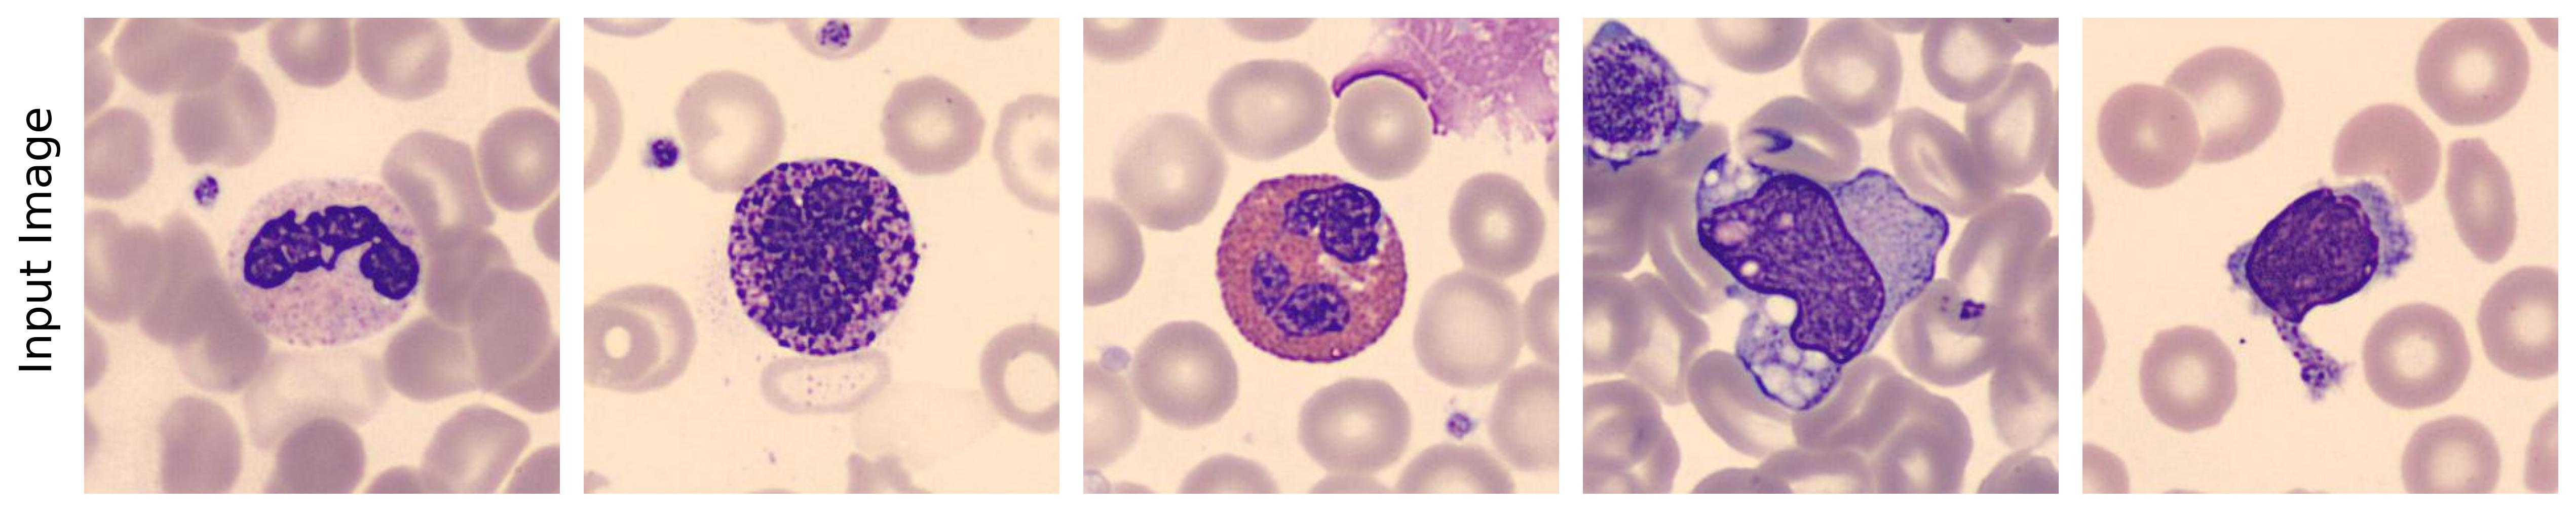

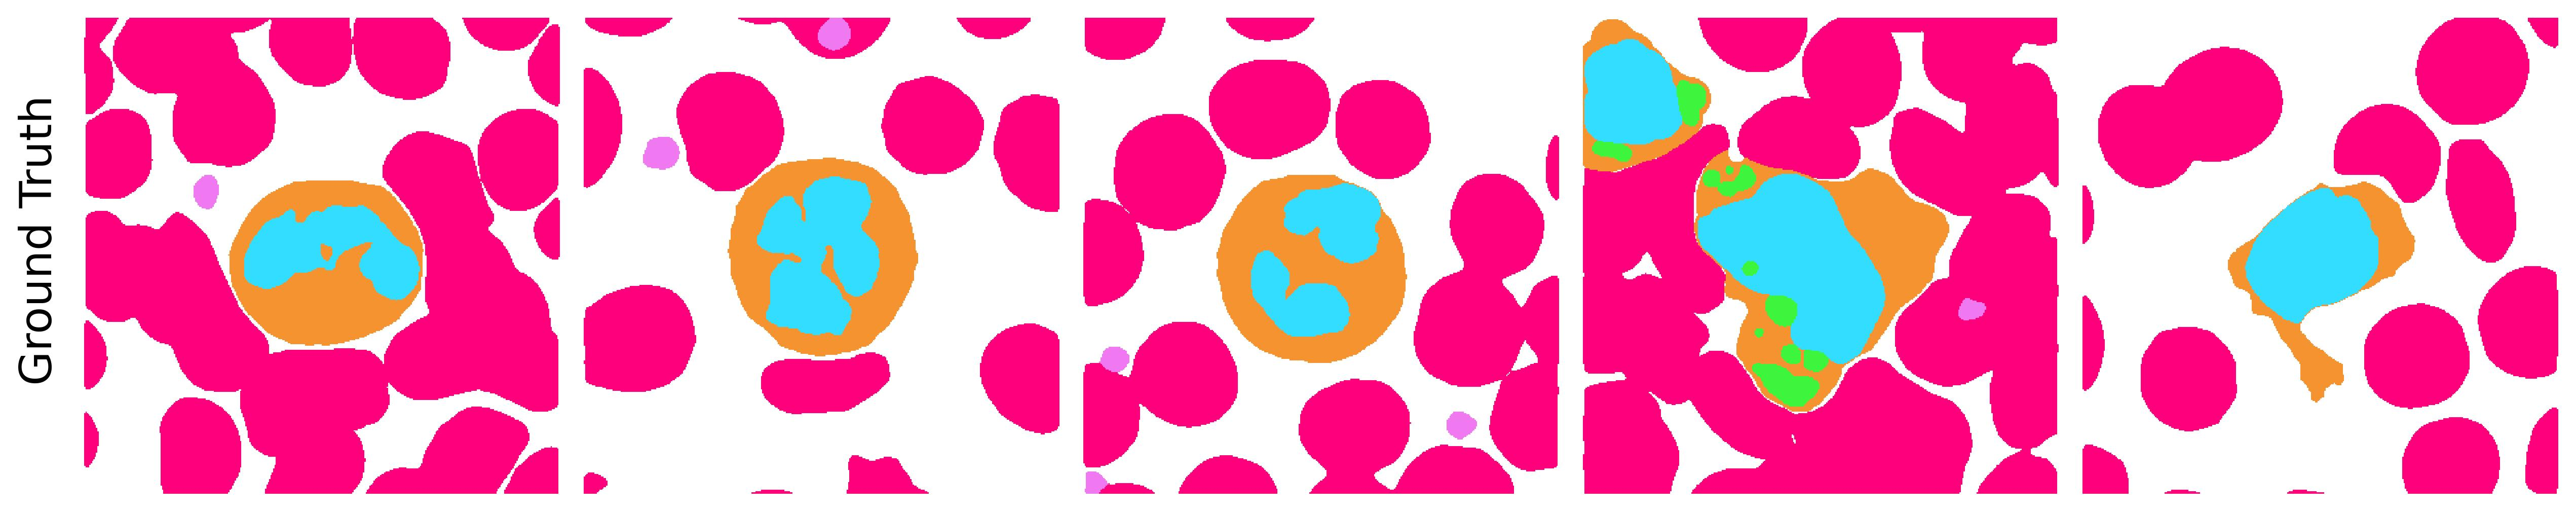

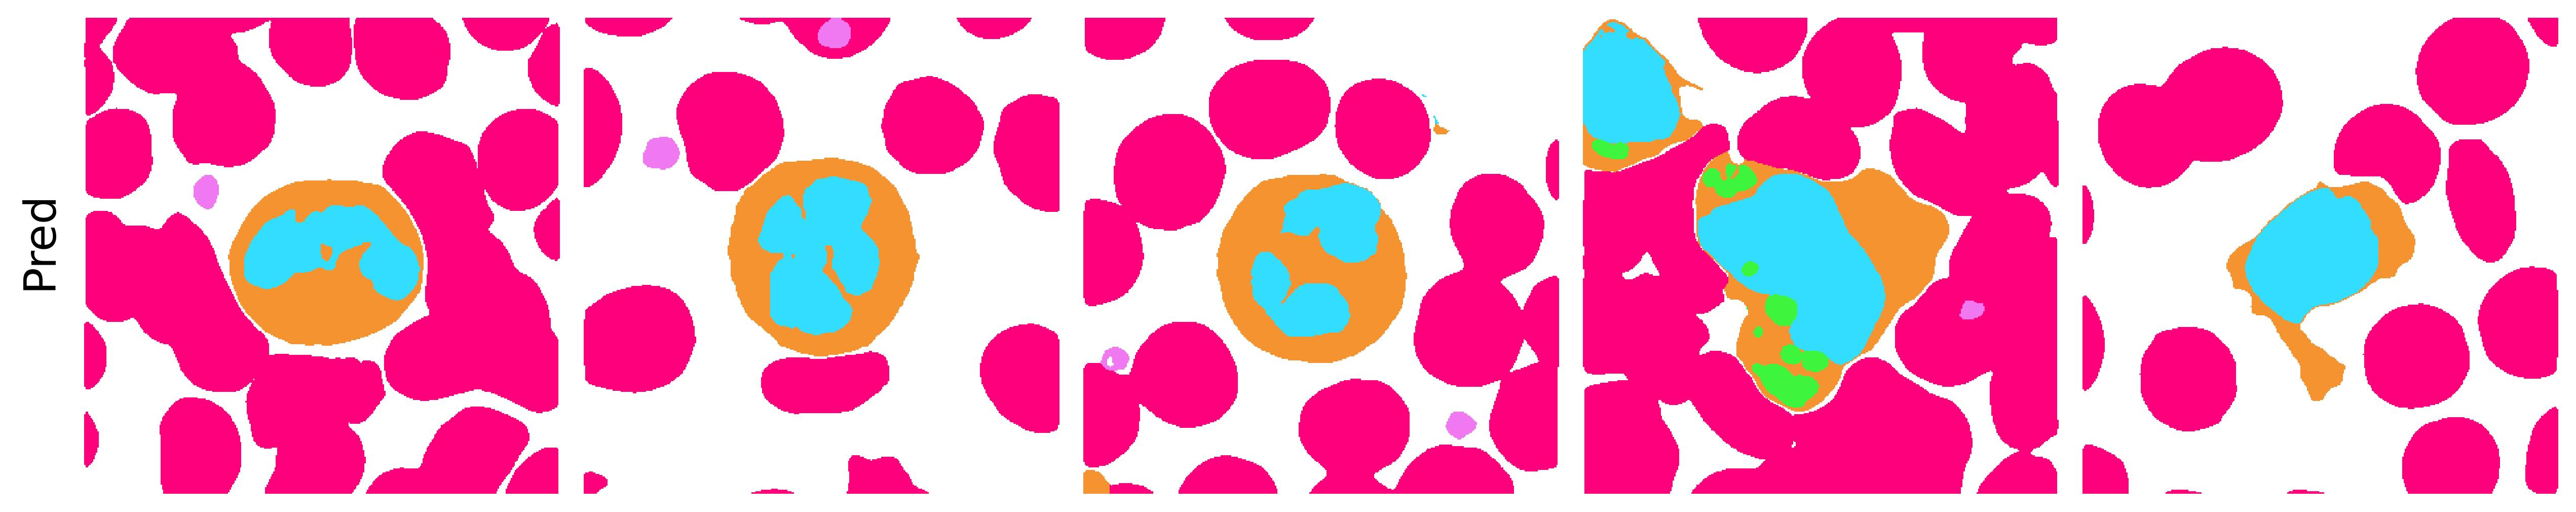

In [9]:
import matplotlib_inline
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats("jpg")
    
val_samples = [
    "SNE_987130_ccrop.jpg",
    "BA_982740_ccrop.jpg",
    "EO_135768_ccrop.jpg",
    "MO_782660_ccrop.jpg",
    "LY_46986_ccrop.jpg"
]
device = "cuda"

# Your class colors
colors = ["#000000","#f59331", "#33ddff", "#f078f0", "#ff007c", "#3df53d"]

# Add alpha channel (bg transparent, others opaque)
colors_rgba = [color + '00' if i == 0 else color + 'FF' 
            for i, color in enumerate(colors)]

cmap = ListedColormap(colors_rgba)

scale = 5
fontsize = 3.5*scale

### INPUTS
fig, axes = plt.subplots(1,5, figsize=(3.5*scale, 3.5*scale), dpi=72*scale)
plt.subplots_adjust(wspace=0.05)
for i,img_name in enumerate(val_samples):
    ax = axes[i]
    path = df.query(f"img_name == '{img_name}'").iloc[0]['img_path']
    img_pil = Image.open(path)
    image = np.array(img_pil)
    ax.imshow(image, extent=[0, image.shape[1], 0, image.shape[0]])
    ax.axis('off')
    ax.axes.get_xaxis().set_visible(False)
    ax.axes.get_yaxis().set_visible(False)

row_title = "Input Image"
fig.text(0.111, 0.5, row_title, ha='center', fontsize=fontsize, rotation='vertical', va='center')  # Set row title

# name = "seg-results-input"
# plt.savefig("./figs/"+name+".pdf", bbox_inches = 'tight',pad_inches = 0.02)
plt.show()
plt.close()

##### GT
modelname = "Ground Truth"
fig, axes = plt.subplots(1,5, figsize=(3.5*scale, 3.5*scale), dpi=72*scale)
plt.subplots_adjust(wspace=0.05)

for i,img_name in enumerate(val_samples):
    ax = axes[i]
    path = df.query(f"img_name == '{img_name}'").iloc[0]['img_path']
    path_mask = path.replace(".jpg","_mask.png")
    seg_mask = np.array(Image.open(path_mask))

    # pred_mask = process_image(img_pil, model, device, return_mask=True)
    ax.imshow(seg_mask, alpha=1.0, vmin=0, vmax=5,cmap=cmap, interpolation='nearest',extent=[0, image.shape[1], 0, image.shape[0]])
    ax.axis('off')
    ax.axes.get_xaxis().set_visible(False)
    ax.axes.get_yaxis().set_visible(False)

fig.text(0.111, 0.5, modelname, ha='center', fontsize=fontsize, rotation='vertical', va='center')  # Set row title
name = f"seg-results-{modelname.replace(' ','-')}"
# plt.savefig("./figs/"+name+".pdf", bbox_inches = 'tight',pad_inches = 0.02)
plt.show()
plt.close()

modelname = "Pred"
fig, axes = plt.subplots(1,5, figsize=(3.5*scale, 3.5*scale), dpi=72*scale)
plt.subplots_adjust(wspace=0.05)

for i,img_name in enumerate(val_samples):
    ax = axes[i]
    path = df.query(f"img_name == '{img_name}'").iloc[0]['img_path']
    pil_image = Image.open(path)
    image_tensor = transform(pil_image)
    with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
        mask_pred = seg_model(image_tensor.cuda().unsqueeze(0))[0].argmax(dim=0).cpu().numpy()
    ax.imshow(mask_pred, alpha=1.0, vmin=0, vmax=5,cmap=cmap, interpolation='nearest',extent=[0, image.shape[1], 0, image.shape[0]])
    ax.axis('off')
    ax.axes.get_xaxis().set_visible(False)
    ax.axes.get_yaxis().set_visible(False)

fig.text(0.111, 0.5, modelname, ha='center', fontsize=fontsize, rotation='vertical', va='center')  # Set row title
name = f"seg-results-{modelname.replace(' ','-')}"
# plt.savefig("./figs/"+name+".pdf", bbox_inches = 'tight',pad_inches = 0.02)
plt.show()
plt.close()

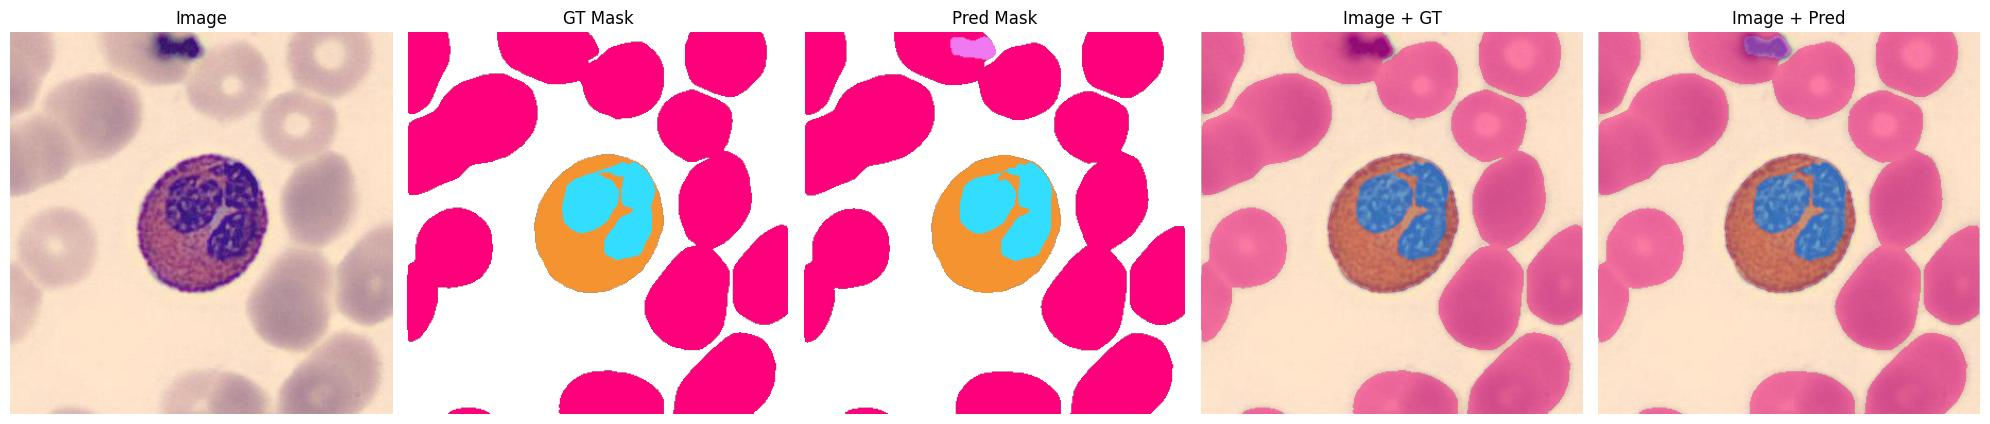

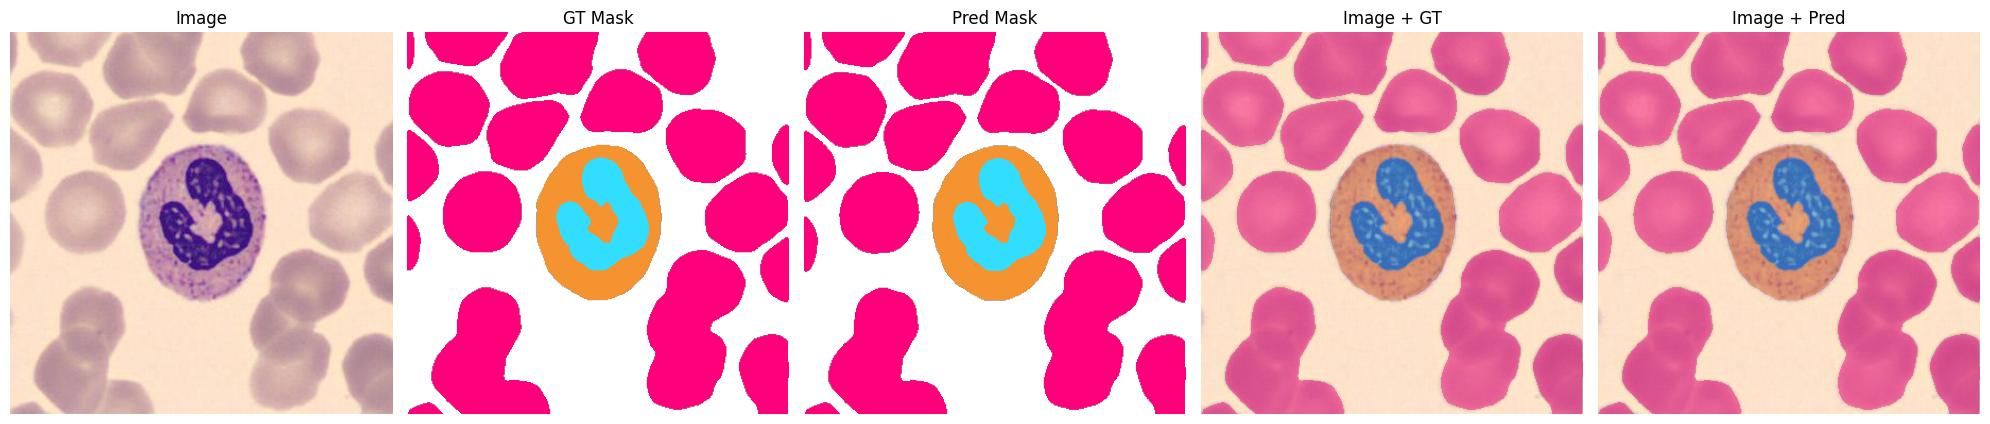

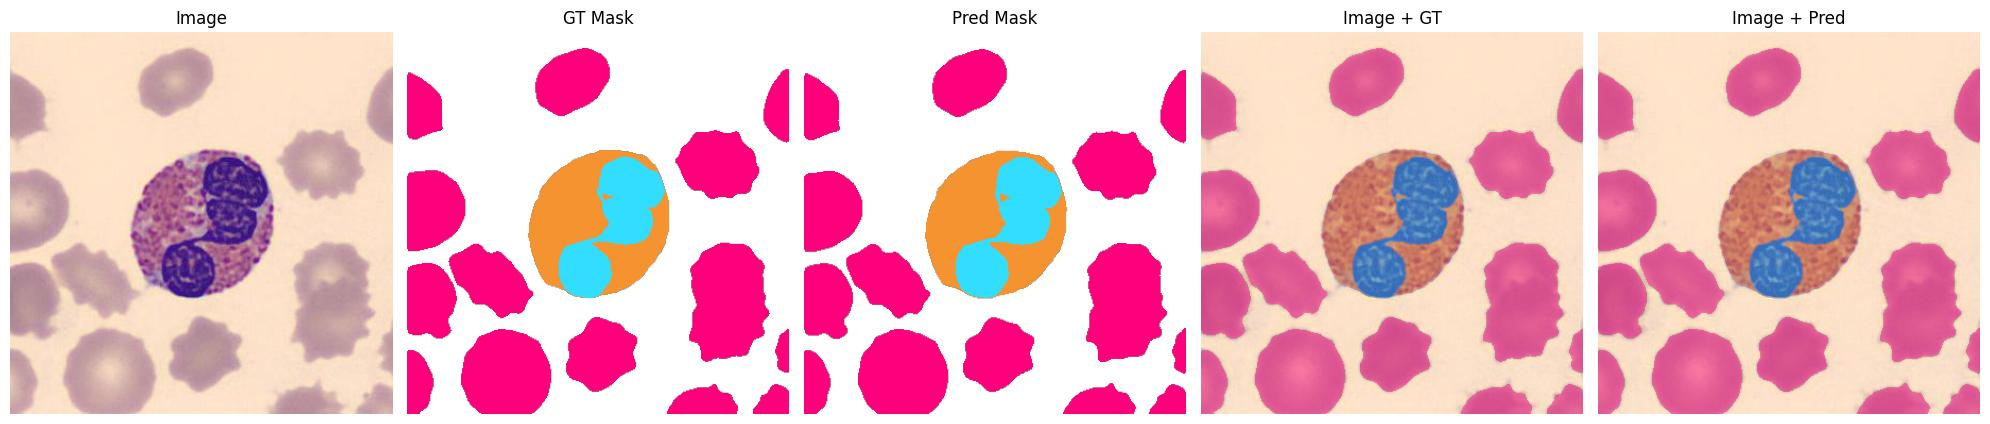

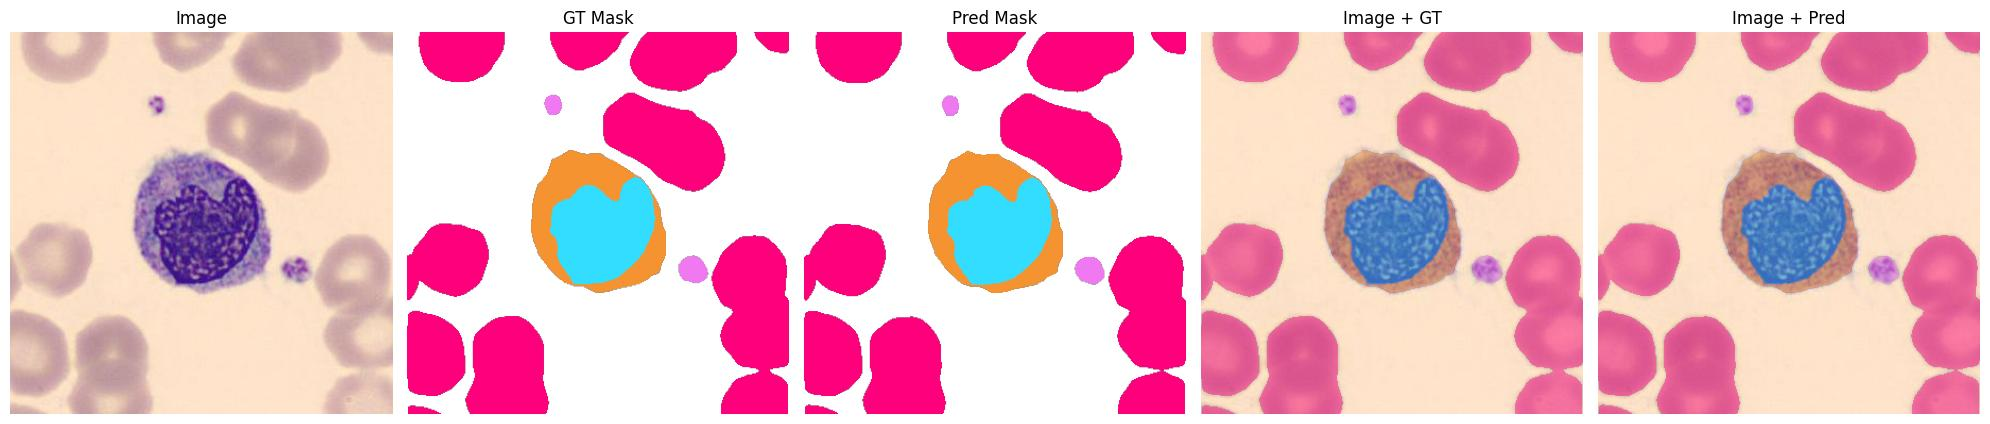

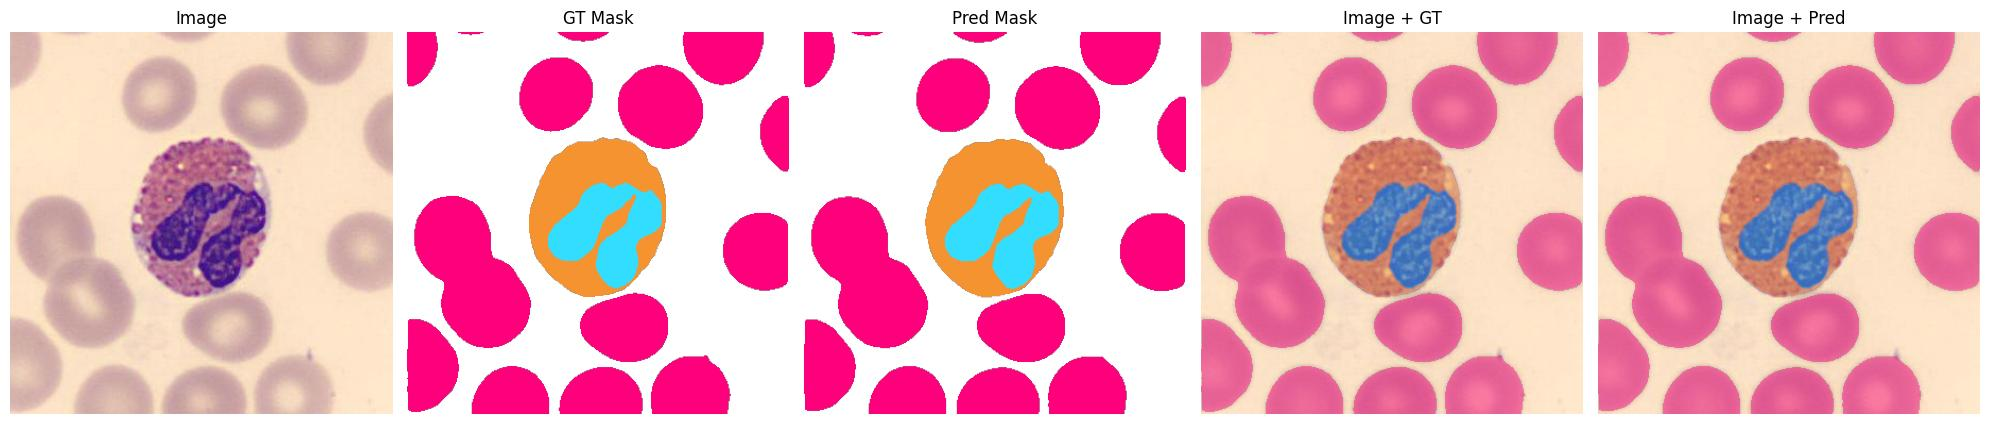

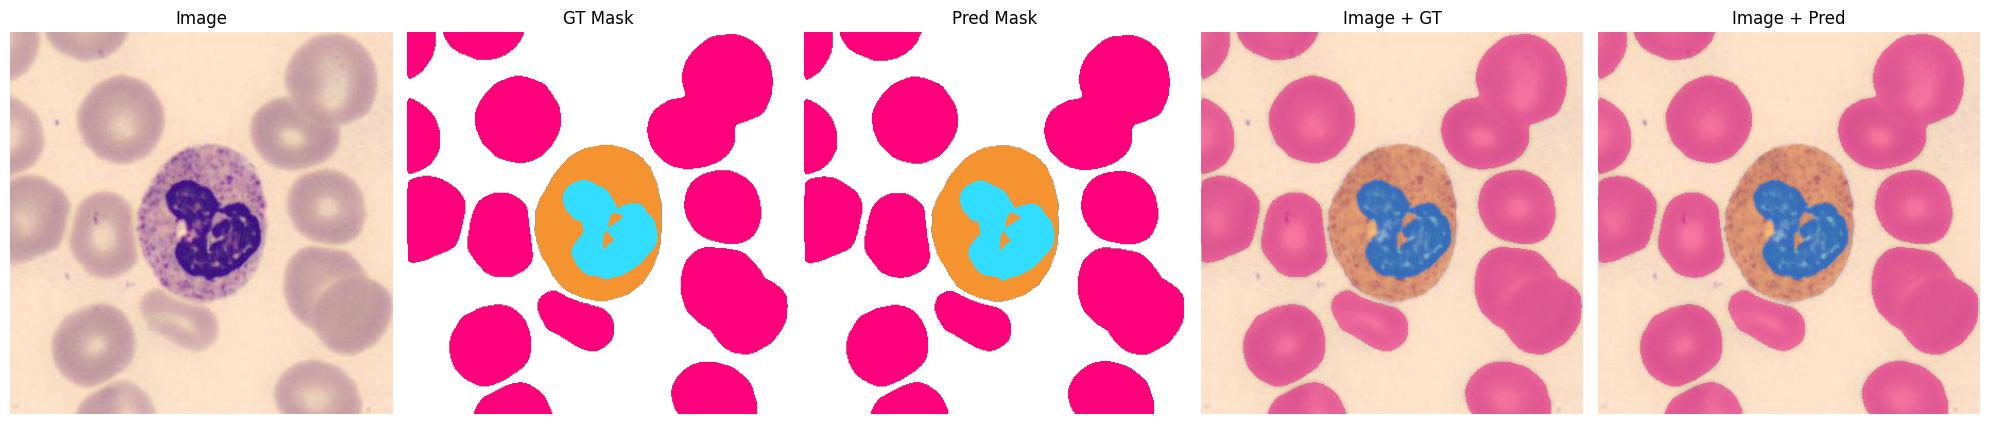

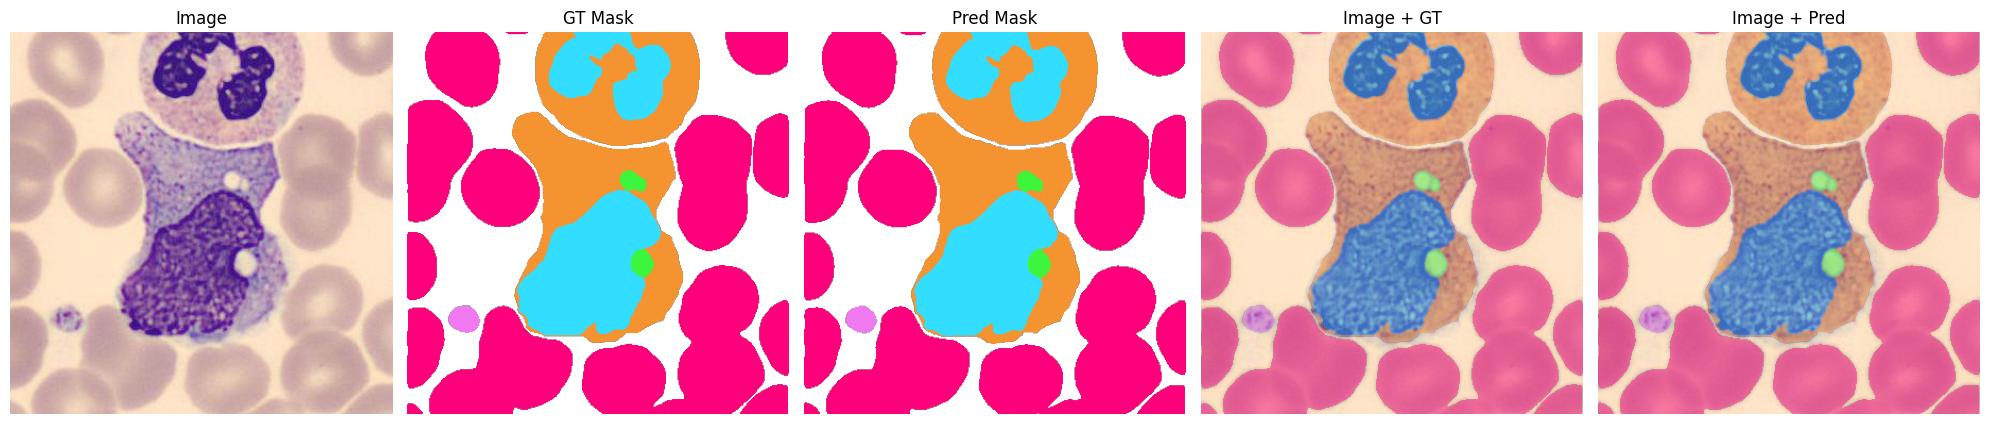

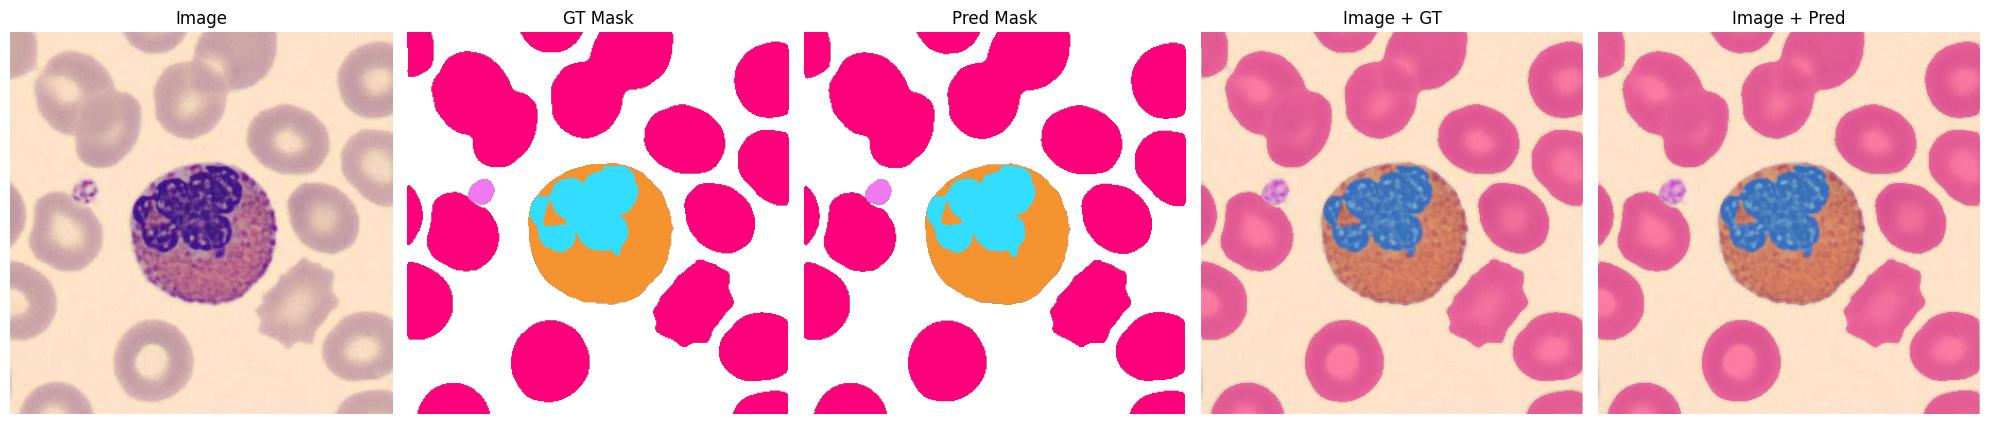

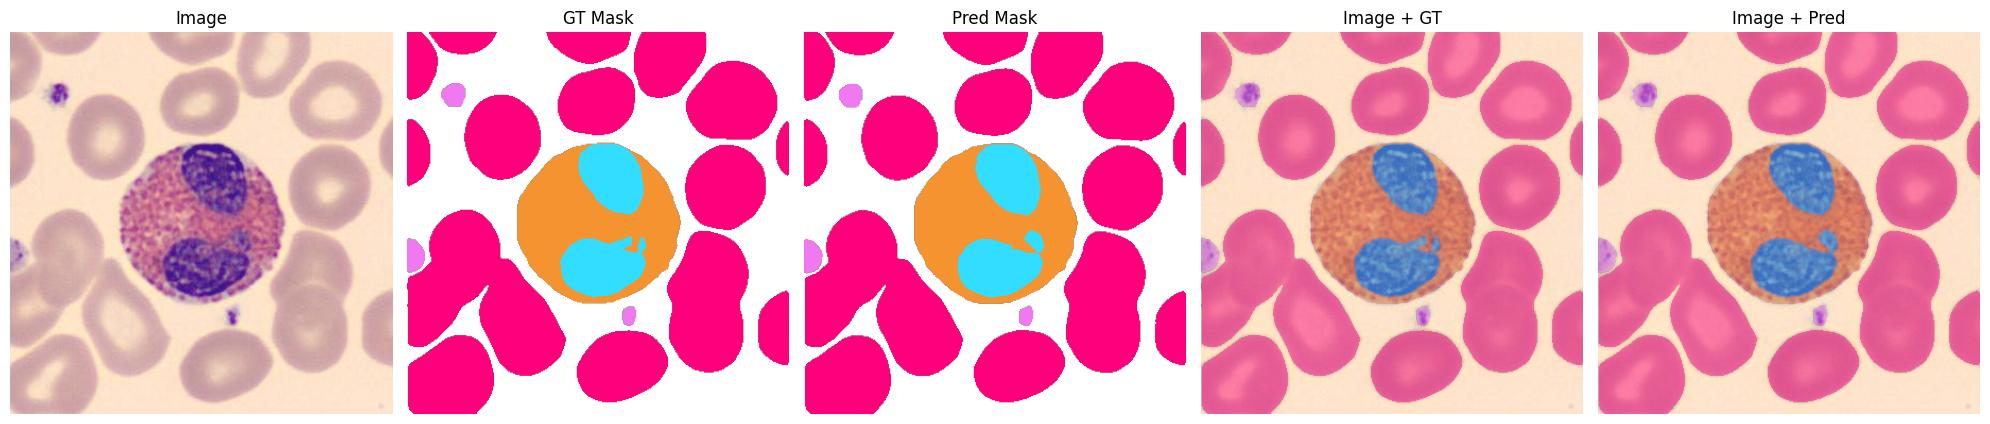

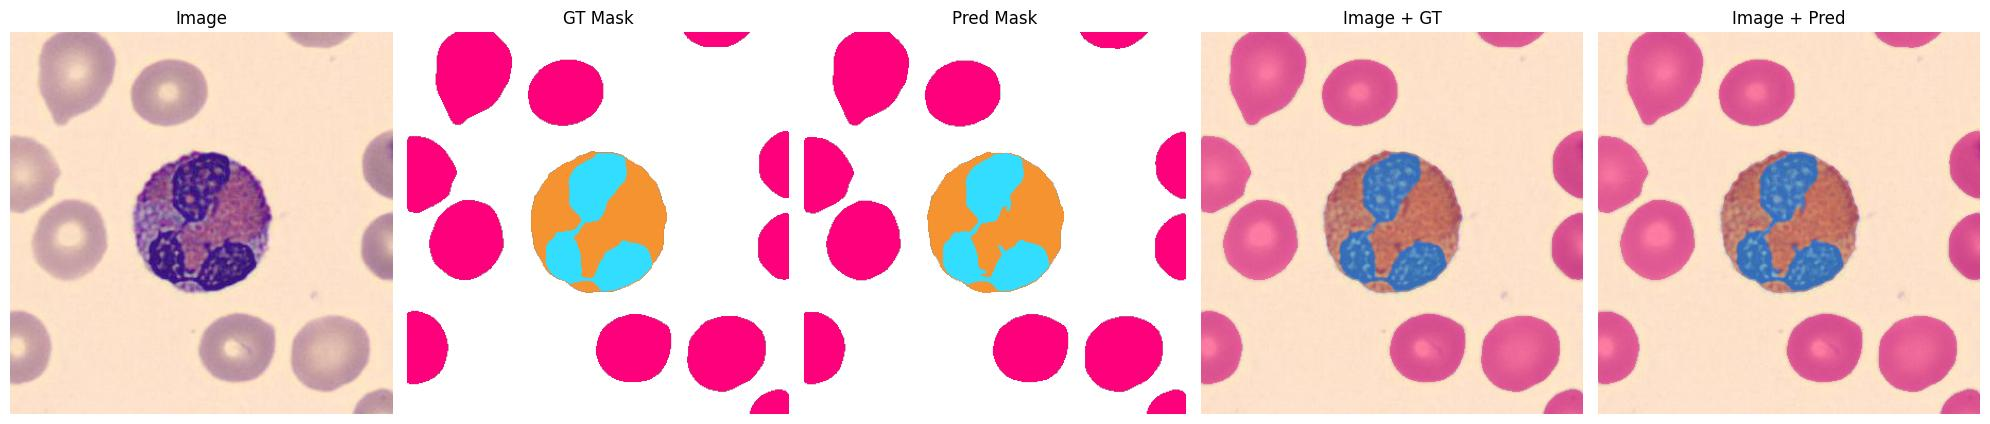

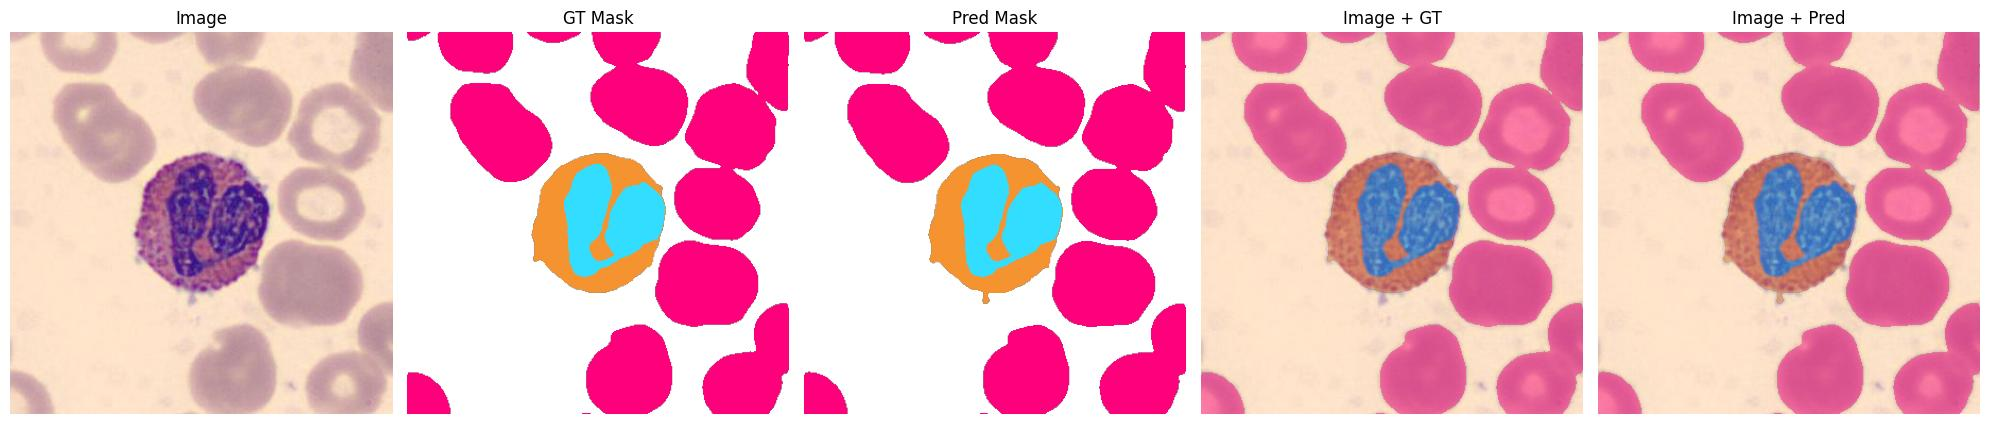

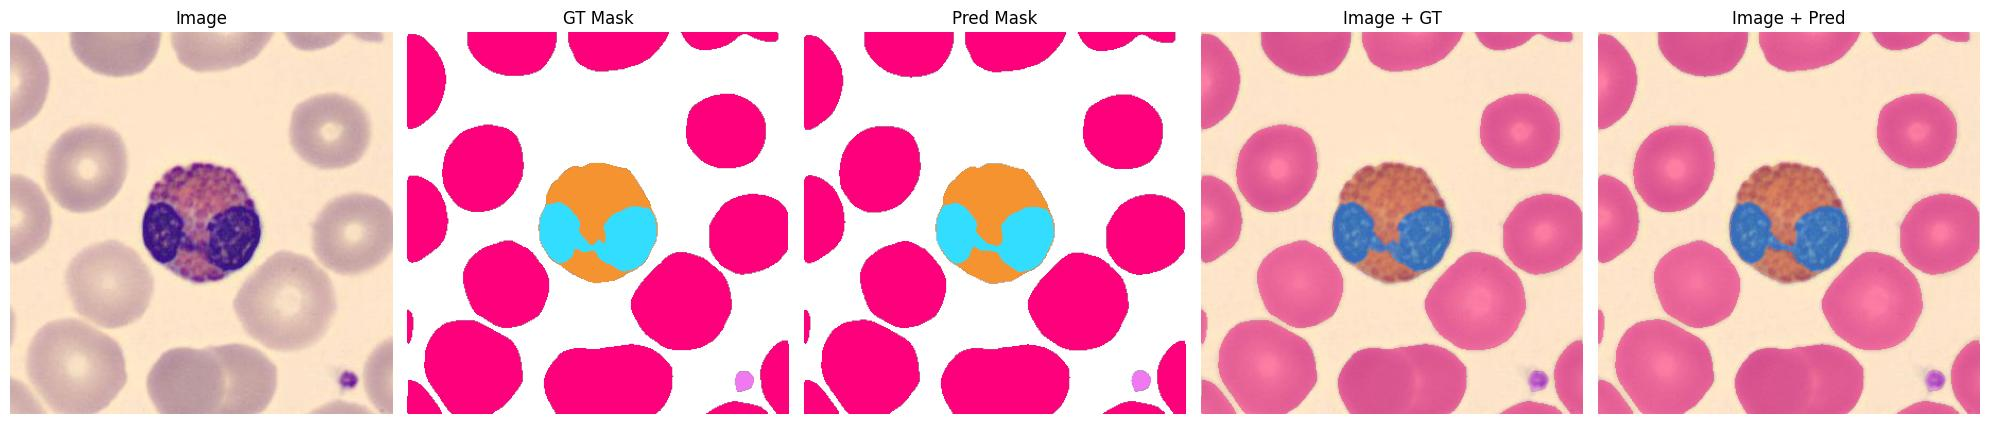

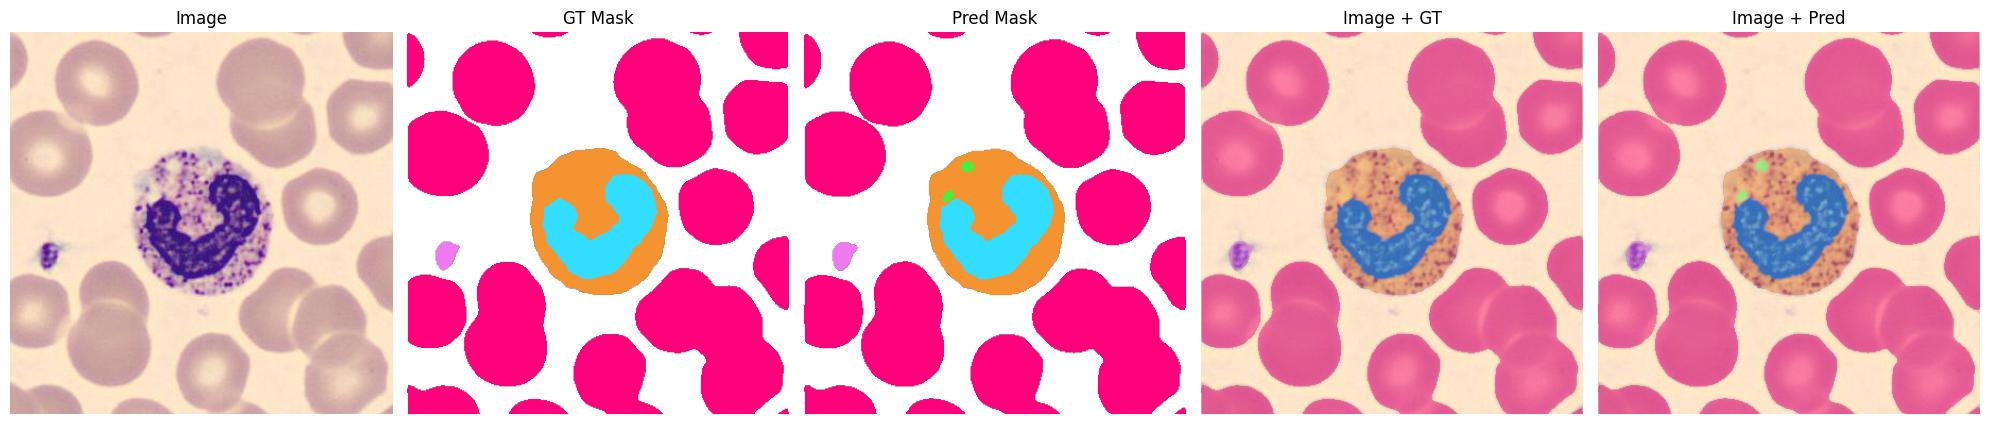

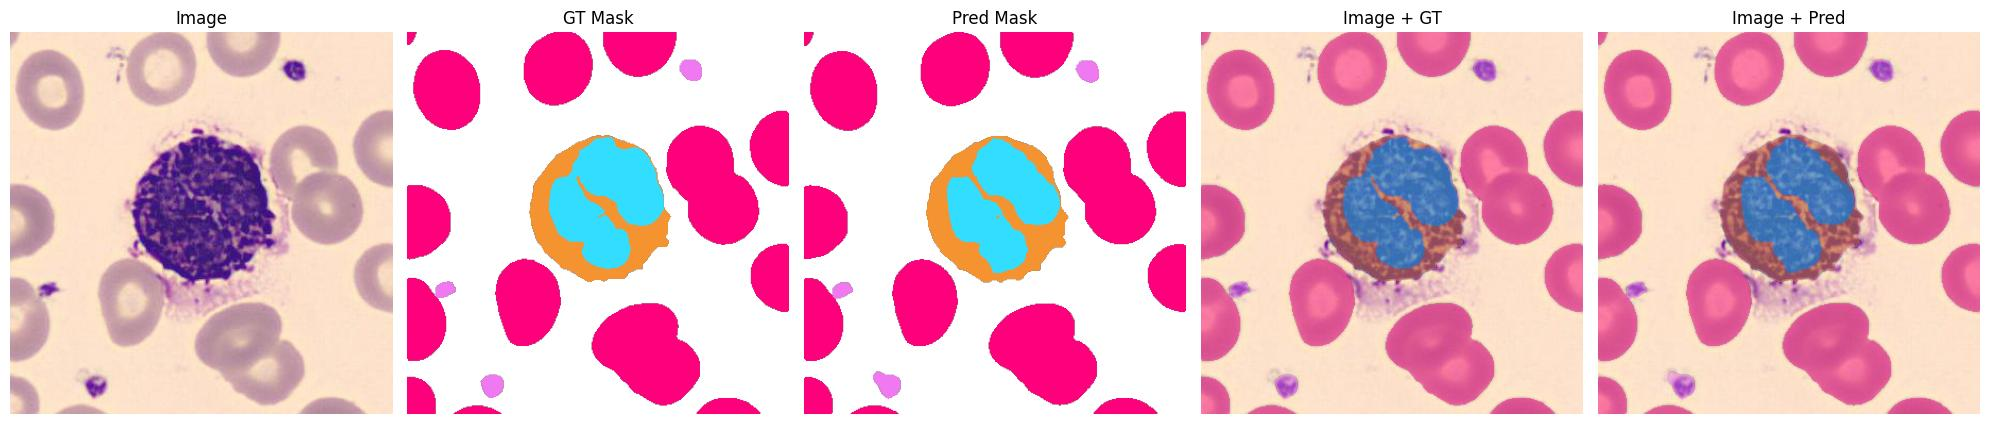

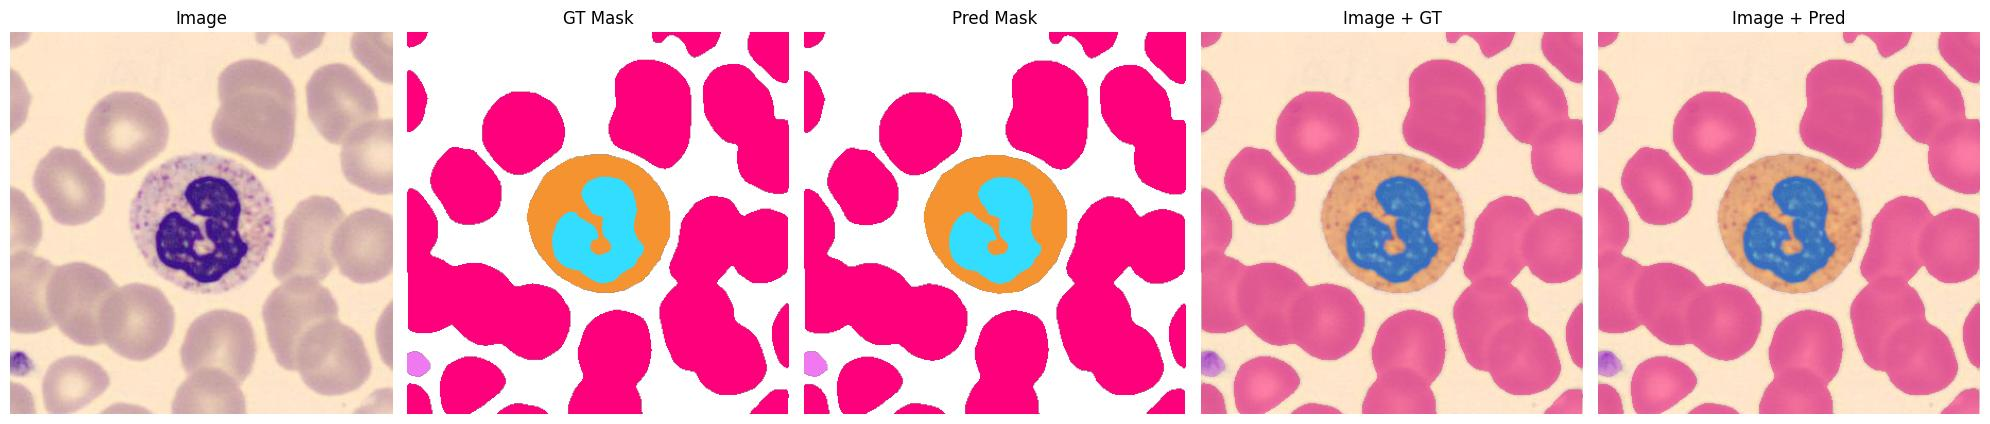

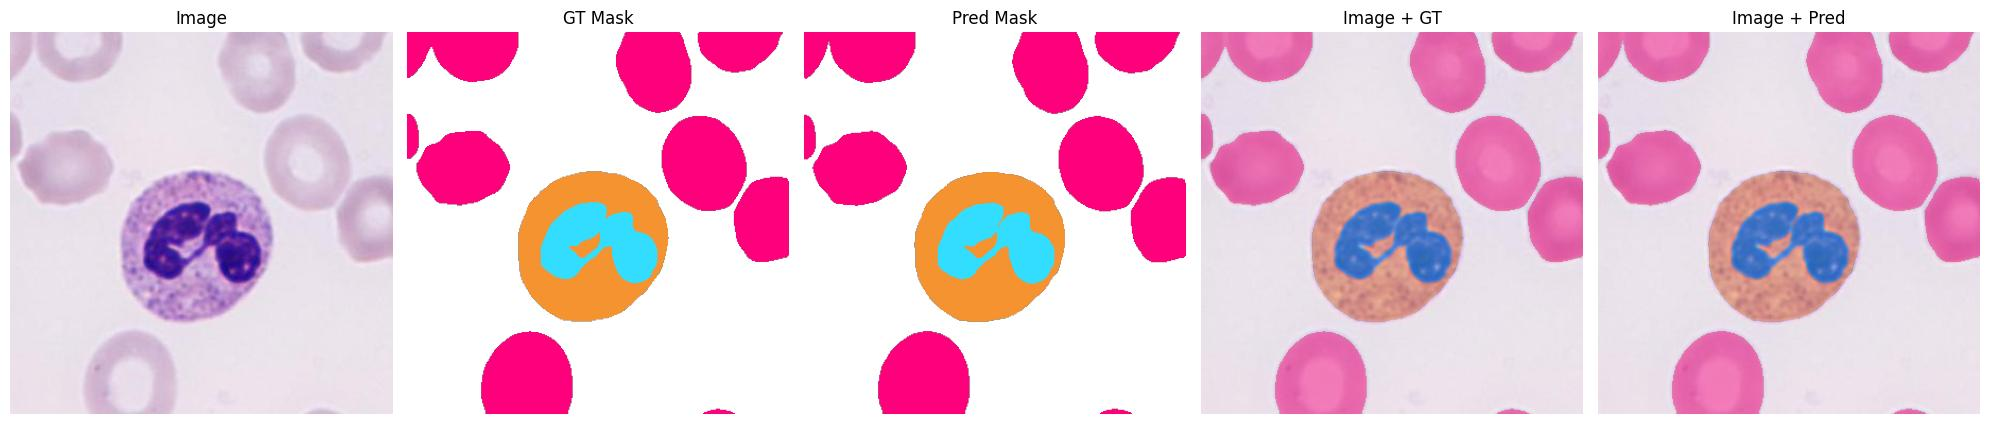

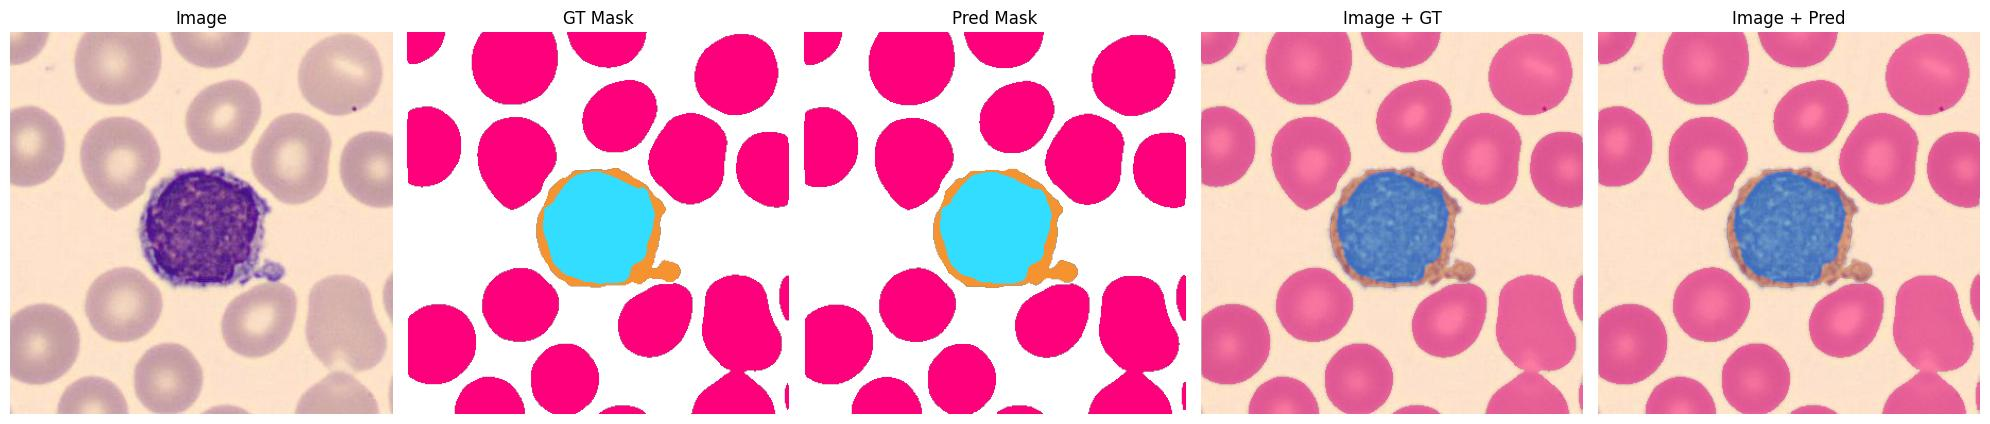

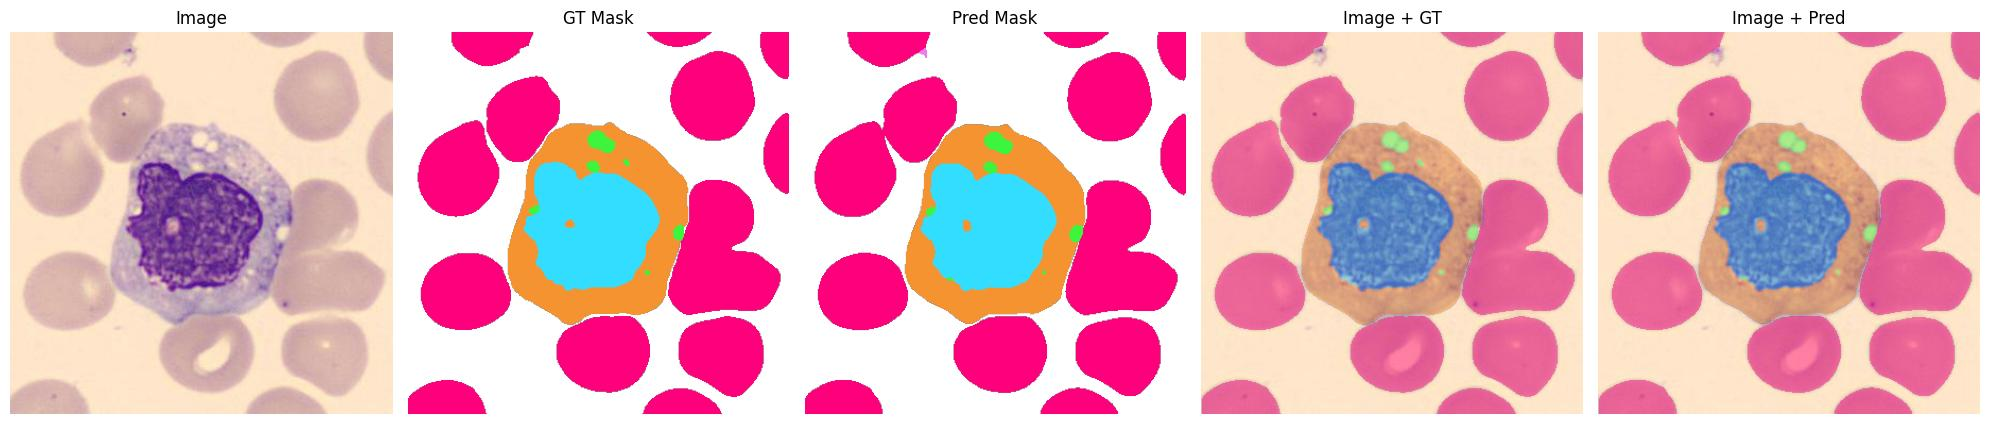

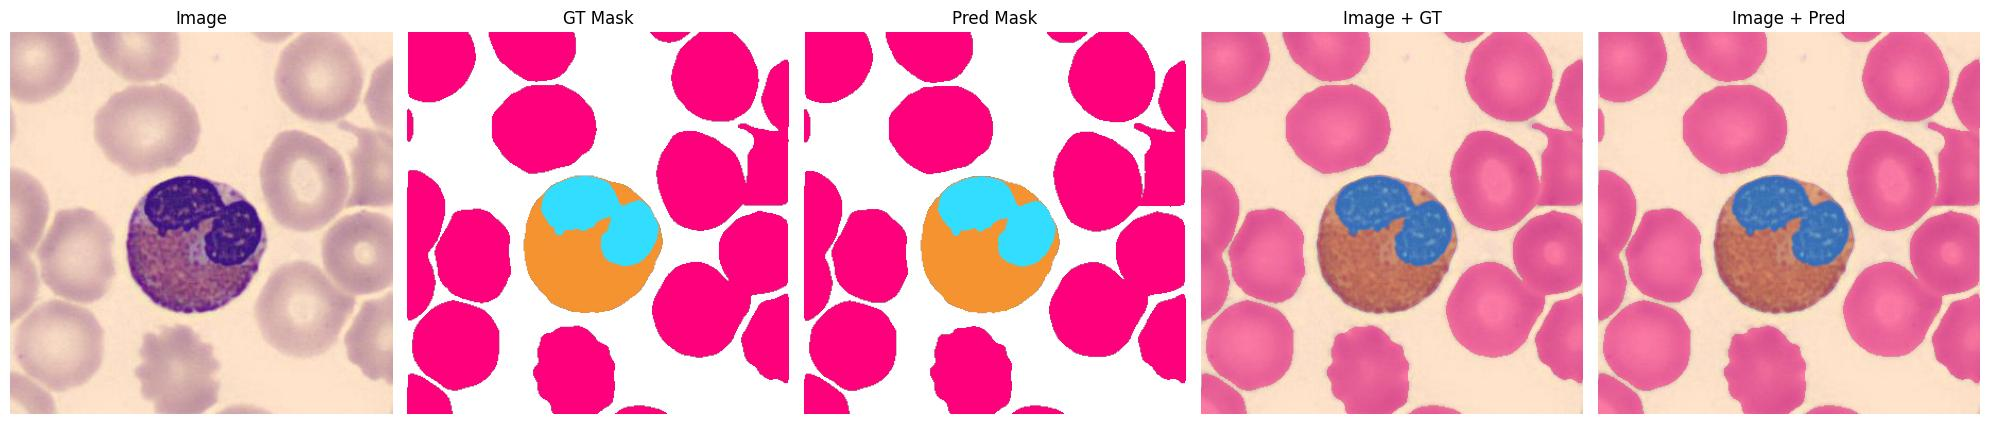

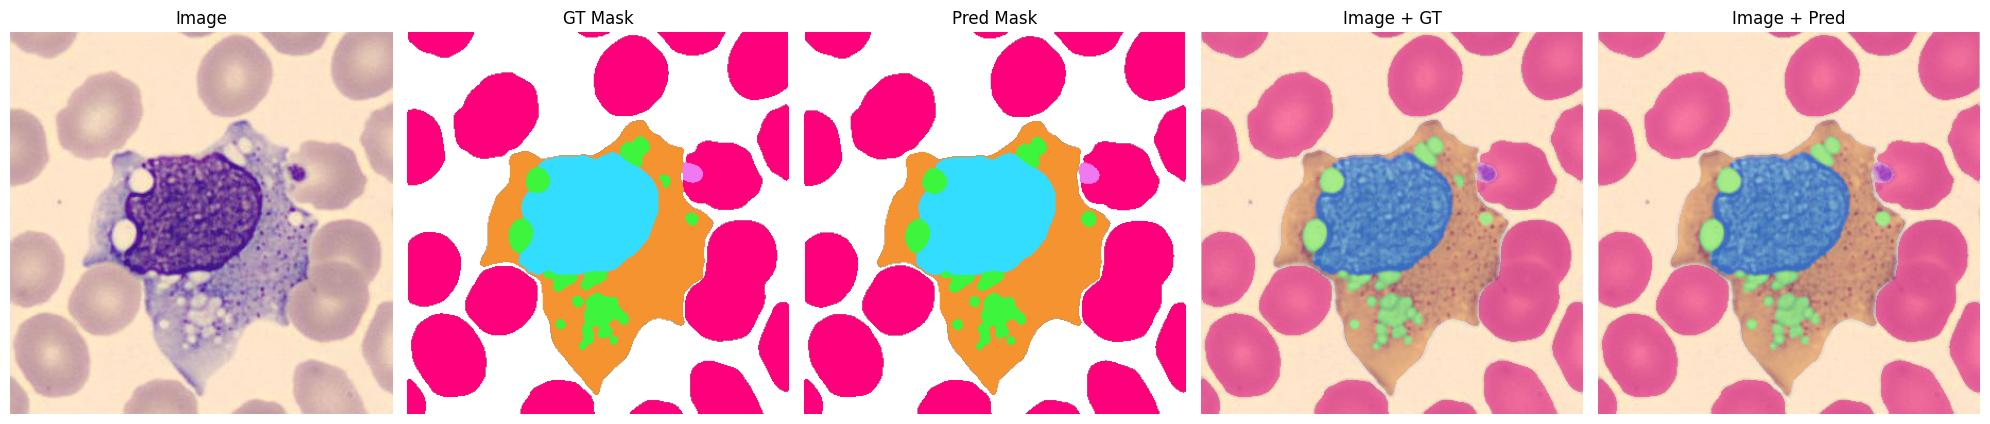

In [10]:
#sample
idx = 102
np.random.seed(1)
indices = np.random.choice(len(df_test), size=20, replace=False)

for idx in indices:

    path = df_test.iloc[idx]['img_path']
    mask_path = df_test.iloc[idx]['mask_path']

    pil_image = Image.open(path)
    image_tensor = transform(pil_image)

    mask_gt = np.array(Image.open(mask_path))
    with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
        mask_pred = seg_model(image_tensor.cuda().unsqueeze(0))[0].argmax(dim=0).cpu().numpy()
        
    #########
    # VISUALIZATION
    #########
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.colors import ListedColormap
    import matplotlib_inline
    matplotlib_inline.backend_inline.set_matplotlib_formats("jpg")

    # Your class colors
    colors = ["#000000","#f59331", "#33ddff", "#f078f0", "#ff007c", "#3df53d"]

    # Add alpha channel (bg transparent, others opaque)
    colors_rgba = [color + '00' if i == 0 else color + 'FF' 
                for i, color in enumerate(colors)]

    cmap = ListedColormap(colors_rgba)

    img_np = np.array(pil_image)

    mask_gt = mask_gt.astype(int)
    mask_pred = mask_pred.astype(int)

    num_classes = len(colors)

    fig, axs = plt.subplots(1, 5, figsize=(20, 5))

    # 1. Image
    axs[0].imshow(img_np)
    axs[0].set_title("Image")
    axs[0].axis('off')

    # 2. GT mask
    axs[1].imshow(mask_gt, cmap=cmap, vmin=0, vmax=num_classes-1)
    axs[1].set_title("GT Mask")
    axs[1].axis('off')

    # 3. Pred mask
    axs[2].imshow(mask_pred, cmap=cmap, vmin=0, vmax=num_classes-1)
    axs[2].set_title("Pred Mask")
    axs[2].axis('off')

    # 4. Overlay GT
    axs[3].imshow(img_np)
    axs[3].imshow(mask_gt, cmap=cmap, vmin=0, vmax=num_classes-1,alpha=0.45)
    axs[3].set_title("Image + GT")
    axs[3].axis('off')

    # 5. Overlay Pred
    axs[4].imshow(img_np)
    axs[4].imshow(mask_pred, cmap=cmap, vmin=0, vmax=num_classes-1,alpha=0.45)
    axs[4].set_title("Image + Pred")
    axs[4].axis('off')

    plt.tight_layout()
    plt.show()
    plt.close()